# Eksperimen SML - Telco Customer Churn
**Nama siswa:** Marvin

Notebook eksperimen ini mengikuti *Template Eksperimen MSML*. Seluruh tahapan
(data loading, EDA, dan preprocessing) dikerjakan secara manual di sini, lalu
dikonversi menjadi `automate_Marvin.py` untuk otomatisasi.


# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Telco Customer Churn** (sumber: IBM Sample Data / Kaggle).
Dataset berisi 7.043 pelanggan perusahaan telekomunikasi dengan 21 kolom yang
mencakup informasi demografi, layanan yang diambil, informasi akun, dan label
**Churn** (apakah pelanggan berhenti berlangganan).

Tujuan eksperimen: membangun model klasifikasi biner untuk memprediksi churn
pelanggan sehingga dapat digunakan pada tahapan modelling berikutnya.


# **2. Import Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
print("Library berhasil diimport.")

Library berhasil diimport.


# **3. Memuat Dataset**

Dataset dimuat dari file CSV mentah menggunakan pandas. Kita periksa beberapa
baris awal, ukuran data, serta tipe datanya untuk memastikan data termuat benar.

In [2]:
RAW_PATH = "../telco_churn_raw/telco_churn_raw.csv"
df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,8364-EWZTQ,Female,0,Yes,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),22.44,1634.99,No
1,5947-PLBXY,Male,1,Yes,No,30,No,No phone service,DSL,Yes,No,Yes,Yes,No,Yes,One year,Yes,Electronic check,71.77,2158.83,Yes
2,3663-ONFIA,Female,1,No,No,9,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),21.47,266.4,No
3,7213-QMVJJ,Female,0,Yes,No,32,Yes,No,DSL,Yes,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,80.77,2554.16,Yes
4,7182-FYFPY,Male,0,No,No,37,Yes,No,Fiber optic,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,86.99,3214.63,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,6564-BMTMC,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.155616,0.362516,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,30.306971,19.743421,0.0,15.0,26.0,43.0,72.0
PhoneService,7043,2,Yes,6357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3578,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini kita memahami karakteristik data: distribusi target, nilai kosong,
korelasi fitur numerik, serta hubungan beberapa fitur kategorikal terhadap churn.

### 4.1 Distribusi target (Churn)

Churn
No     4368
Yes    2675
Name: count, dtype: int64

Proporsi churn:
Churn
No     62.02
Yes    37.98
Name: proportion, dtype: float64


/sessions/amazing-admiring-mayer/tmp/ipykernel_7/2614082430.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


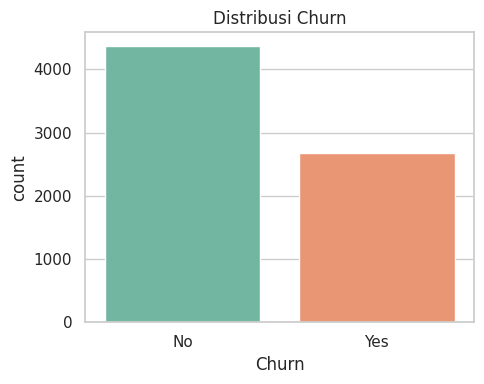

In [5]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print("\nProporsi churn:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Distribusi Churn")
plt.tight_layout()
plt.show()

### 4.2 Pengecekan nilai kosong & anomali tipe data

In [6]:
# TotalCharges tersimpan sebagai object karena pelanggan baru (tenure 0) kosong.
print("Tipe TotalCharges:", df["TotalCharges"].dtype)
tc_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Jumlah TotalCharges kosong/blank:", tc_numeric.isna().sum())
print("\nMissing values per kolom:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "Tidak ada NaN eksplisit.")
print("\nJumlah duplikat baris:", df.duplicated().sum())

Tipe TotalCharges: object
Jumlah TotalCharges kosong/blank: 18

Missing values per kolom:
Tidak ada NaN eksplisit.

Jumlah duplikat baris: 0


### 4.3 Distribusi fitur numerik

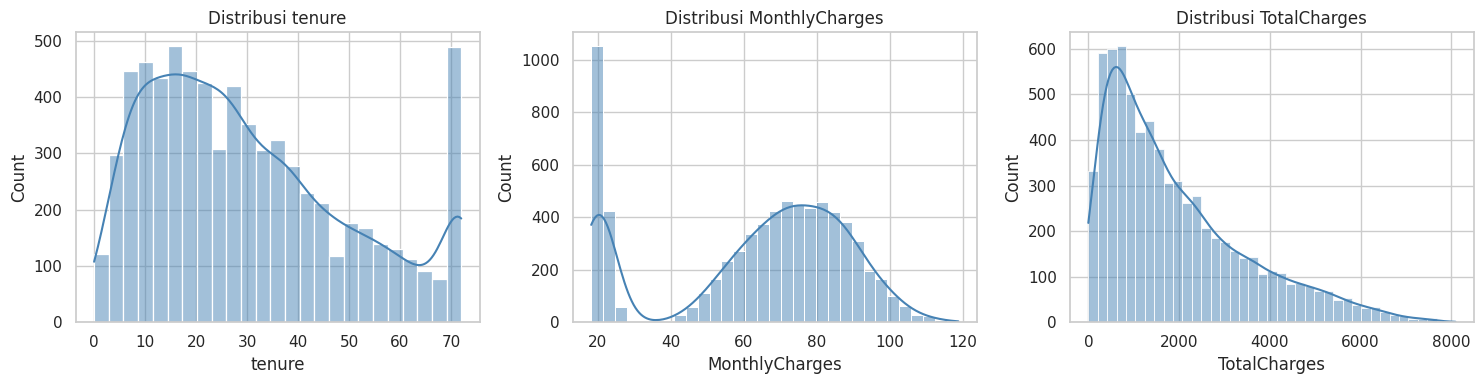

In [7]:
num_cols = ["tenure", "MonthlyCharges"]
df_num = df.copy()
df_num["TotalCharges"] = pd.to_numeric(df_num["TotalCharges"], errors="coerce")
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df_num[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

### 4.4 Korelasi fitur numerik

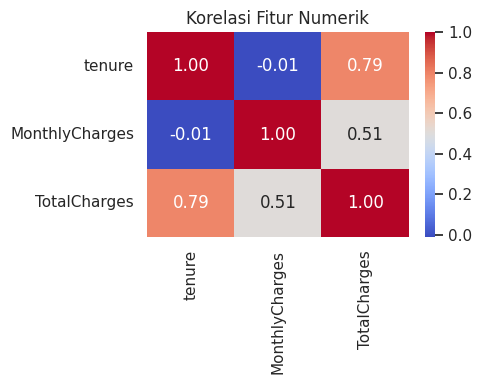

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,-0.009495,0.792682
MonthlyCharges,-0.009495,1.000000,0.505099
TotalCharges,0.792682,0.505099,1.000000


In [8]:
plt.figure(figsize=(5,4))
corr = df_num[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()
corr

### 4.5 Churn berdasarkan fitur kategorikal kunci

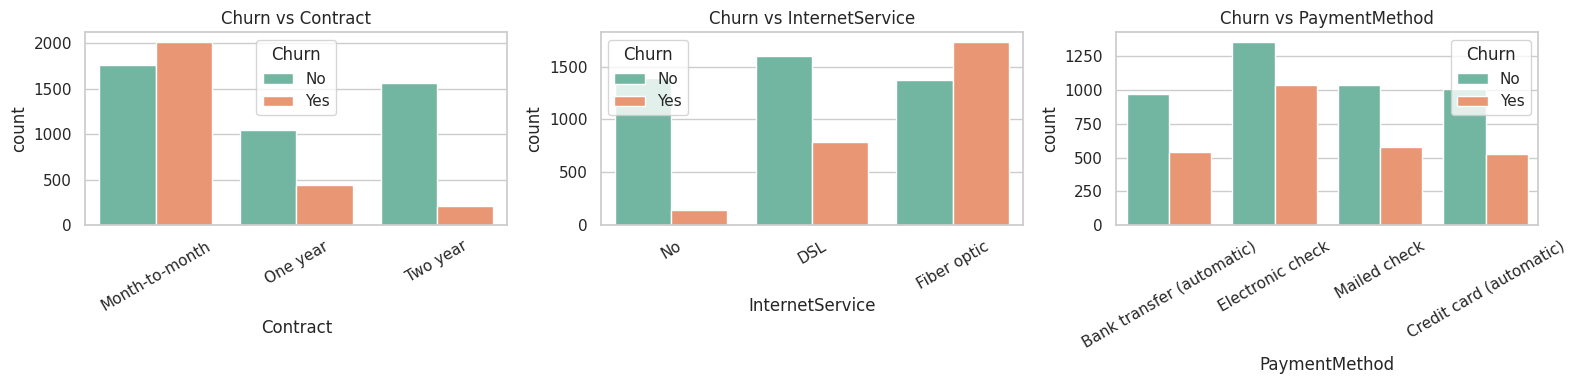

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    sns.countplot(x=col, hue="Churn", data=df, ax=ax, palette="Set2")
    ax.set_title(f"Churn vs {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [10]:
# Rata-rata churn (numerik) per tipe kontrak
tmp = df.copy()
tmp["ChurnFlag"] = (tmp["Churn"] == "Yes").astype(int)
print(tmp.groupby("Contract")["ChurnFlag"].mean().round(3))

Contract
Month-to-month    0.535
One year          0.298
Two year          0.118
Name: ChurnFlag, dtype: float64


**Insight EDA:**
- Kelas churn tidak seimbang (mayoritas pelanggan *No churn*).
- `TotalCharges` mengandung nilai kosong untuk pelanggan dengan `tenure = 0`.
- `tenure` dan `TotalCharges` berkorelasi kuat (pelanggan lama -> total tagihan besar).
- Pelanggan **Month-to-month**, memakai **Fiber optic**, dan membayar via
  **Electronic check** memiliki tingkat churn tertinggi.


# **5. Data Preprocessing**

Tahapan preprocessing berikut menjadi acuan pembuatan `automate_Marvin.py`:
1. Menghapus kolom identifier (`customerID`).
2. Menangani nilai kosong: konversi `TotalCharges` ke numerik dan isi NaN dengan 0.
3. Menghapus baris duplikat.
4. Encoding target dan fitur kategorikal (binary mapping + one-hot).
5. Standardisasi fitur numerik.
6. Train/test split (stratified 80/20).


### 5.1 Menghapus identifier & menangani nilai kosong

In [11]:
data = df.copy()
data = data.drop(columns=["customerID"])
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce").fillna(0.0)
print("Sisa NaN:", int(data.isna().sum().sum()))

Sisa NaN: 0


### 5.2 Menghapus duplikat

In [12]:
before = len(data)
data = data.drop_duplicates().reset_index(drop=True)
print(f"Duplikat dihapus: {before - len(data)} | shape sekarang: {data.shape}")

Duplikat dihapus: 0 | shape sekarang: (7043, 20)


### 5.3 Encoding kategorikal

In [13]:
TARGET = "Churn"
BINARY_MAP_COLS = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
NOMINAL_COLS = ["gender", "MultipleLines", "InternetService", "OnlineSecurity",
                "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
                "StreamingMovies", "Contract", "PaymentMethod"]

data[TARGET] = (data[TARGET] == "Yes").astype(int)
for col in BINARY_MAP_COLS:
    data[col] = (data[col] == "Yes").astype(int)

data = pd.get_dummies(data, columns=NOMINAL_COLS, drop_first=True)
bool_cols = data.select_dtypes(include="bool").columns
data[bool_cols] = data[bool_cols].astype(int)
print("Shape setelah encoding:", data.shape)
data.head()

Shape setelah encoding: (7043, 31)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,1,72,1,1,22.44,1634.99,0,0,0,0,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,0
1,1,1,0,30,0,1,71.77,2158.83,1,1,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,1,0,0,1,0
2,1,0,0,9,1,0,21.47,266.40,0,0,0,1,0,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,0
3,0,1,0,32,1,1,80.77,2554.16,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,1,0,0,0,1,0
4,0,0,0,37,1,1,86.99,3214.63,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1


### 5.4 Standardisasi + train/test split

In [14]:
NUMERIC_COLS = ["tenure", "MonthlyCharges", "TotalCharges"]
X = data.drop(columns=[TARGET])
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])
X_test[NUMERIC_COLS] = scaler.transform(X_test[NUMERIC_COLS])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Distribusi target train:\n", y_train.value_counts(normalize=True).round(3))

X_train: (5634, 30) | X_test: (1409, 30)
Distribusi target train:
 Churn
0    0.62
1    0.38
Name: proportion, dtype: float64


### 5.5 Menyimpan hasil preprocessing

In [15]:
import os
OUT_DIR = "telco_churn_preprocessing"
os.makedirs(OUT_DIR, exist_ok=True)

train = X_train.copy(); train[TARGET] = y_train.values
test = X_test.copy();  test[TARGET] = y_test.values
data.to_csv(os.path.join(OUT_DIR, "telco_churn_clean.csv"), index=False)
train.to_csv(os.path.join(OUT_DIR, "train.csv"), index=False)
test.to_csv(os.path.join(OUT_DIR, "test.csv"), index=False)

import joblib
joblib.dump(scaler, os.path.join(OUT_DIR, "scaler.joblib"))
print("Data siap latih tersimpan di:", OUT_DIR)
print(os.listdir(OUT_DIR))

Data siap latih tersimpan di: telco_churn_preprocessing
['scaler.joblib', 'telco_churn_clean.csv', 'test.csv', 'train.csv']


### 5.6 Konversi ke otomatisasi

Seluruh langkah di atas telah dikonversi menjadi fungsi-fungsi pada
`automate_Marvin.py`. Verifikasi bahwa modul otomatisasi menghasilkan bentuk
data yang identik:

In [16]:
from automate_Marvin import preprocess_data
result = preprocess_data(RAW_PATH)  # output_dir=None -> hanya kembalikan data
print("Otomatisasi menghasilkan:")
print("  X_train:", result["X_train"].shape)
print("  X_test :", result["X_test"].shape)
print("  jumlah fitur:", len(result["feature_names"]))
assert result["X_train"].shape[1] == X_train.shape[1], "Jumlah fitur harus sama!"
print("\nOK - hasil otomatisasi konsisten dengan eksperimen manual.")

Otomatisasi menghasilkan:
  X_train: (5634, 30)
  X_test : (1409, 30)
  jumlah fitur: 30

OK - hasil otomatisasi konsisten dengan eksperimen manual.
